# Day 11/60 — Rate Limiter (Part 1): High-Level Design

## System Design Series

**Topic:** A rate limiter controls the rate of traffic sent by a client or service. It limits the number of client requests allowed over a specified period — excess requests are blocked with an HTTP 429 Too Many Requests response.

**Examples:**
- A user can write no more than 2 posts per second
- A maximum of 10 accounts per day can be created from the same IP address

**What we cover:**
- Core concept: allow vs block request flow
- Where to place the rate limiter: client, server, or middleware/API gateway
- API gateway as rate limiter with HTTP 429 exception handling
- Distributed rate limiting: why local counters fail, and Redis as the solution
- Six design requirements mapped to architecture decisions
- Decision guide: server-side vs API gateway
- Architecture evolution and Day 11 scorecard

---

## 1. Setup: Libraries & Colour Palette

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import numpy as np

plt.rcParams.update({'font.family': 'DejaVu Sans', 'figure.dpi': 120})

C_ALLOW   = '#27AE60'   # green  — allowed request
C_BLOCK   = '#C44E52'   # red    — blocked / 429
C_RL      = '#E67E22'   # amber  — rate limiter component
C_GW      = '#2980B9'   # blue   — API gateway
C_SERVER  = '#8E44AD'   # purple — API / backend server
C_CLIENT  = '#2E86AB'   # teal   — client
C_MIDDLE  = '#F39C12'   # gold   — middleware
C_GRAY    = '#F8F9FA'
C_ORANGE  = '#DD8452'

print("Libraries loaded. Day 11 ready.")


Libraries loaded. Day 11 ready.


### What this does

Loads Matplotlib and NumPy with the Day 11 colour palette:

| Constant | Colour | Meaning |
|---|---|---|
| `C_ALLOW` | Green | Allowed request (within limit) |
| `C_BLOCK` | Red | Blocked request — HTTP 429 |
| `C_RL` | Amber | Rate limiter component |
| `C_GW` | Blue | API gateway |
| `C_SERVER` | Purple | API / backend server |
| `C_CLIENT` | Teal | Client (user / service caller) |
| `C_MIDDLE` | Gold | Middleware layer |

## 2. Rate Limiter: Core Concept & Benefits

> "A rate limiter is used to control the rate of traffic sent by a client or a service. A rate limiter limits the number of client requests allowed to be sent over a specified period. If the API request count exceeds the threshold defined by the rate limiter, all the excess calls are blocked." — Day 11

**The mechanism in one sentence:**
The rate limiter counts requests from each client within a sliding time window. If the count exceeds the threshold, the request is immediately rejected with HTTP 429 — it never reaches the backend.

**Three core benefits:**
1. **DoS prevention** — limits flood attacks before they exhaust server resources
2. **Cost control** — fewer servers needed; downstream paid APIs (SMS, ML) protected
3. **Bot prevention** — crawlers and misbehaving clients capped per identity

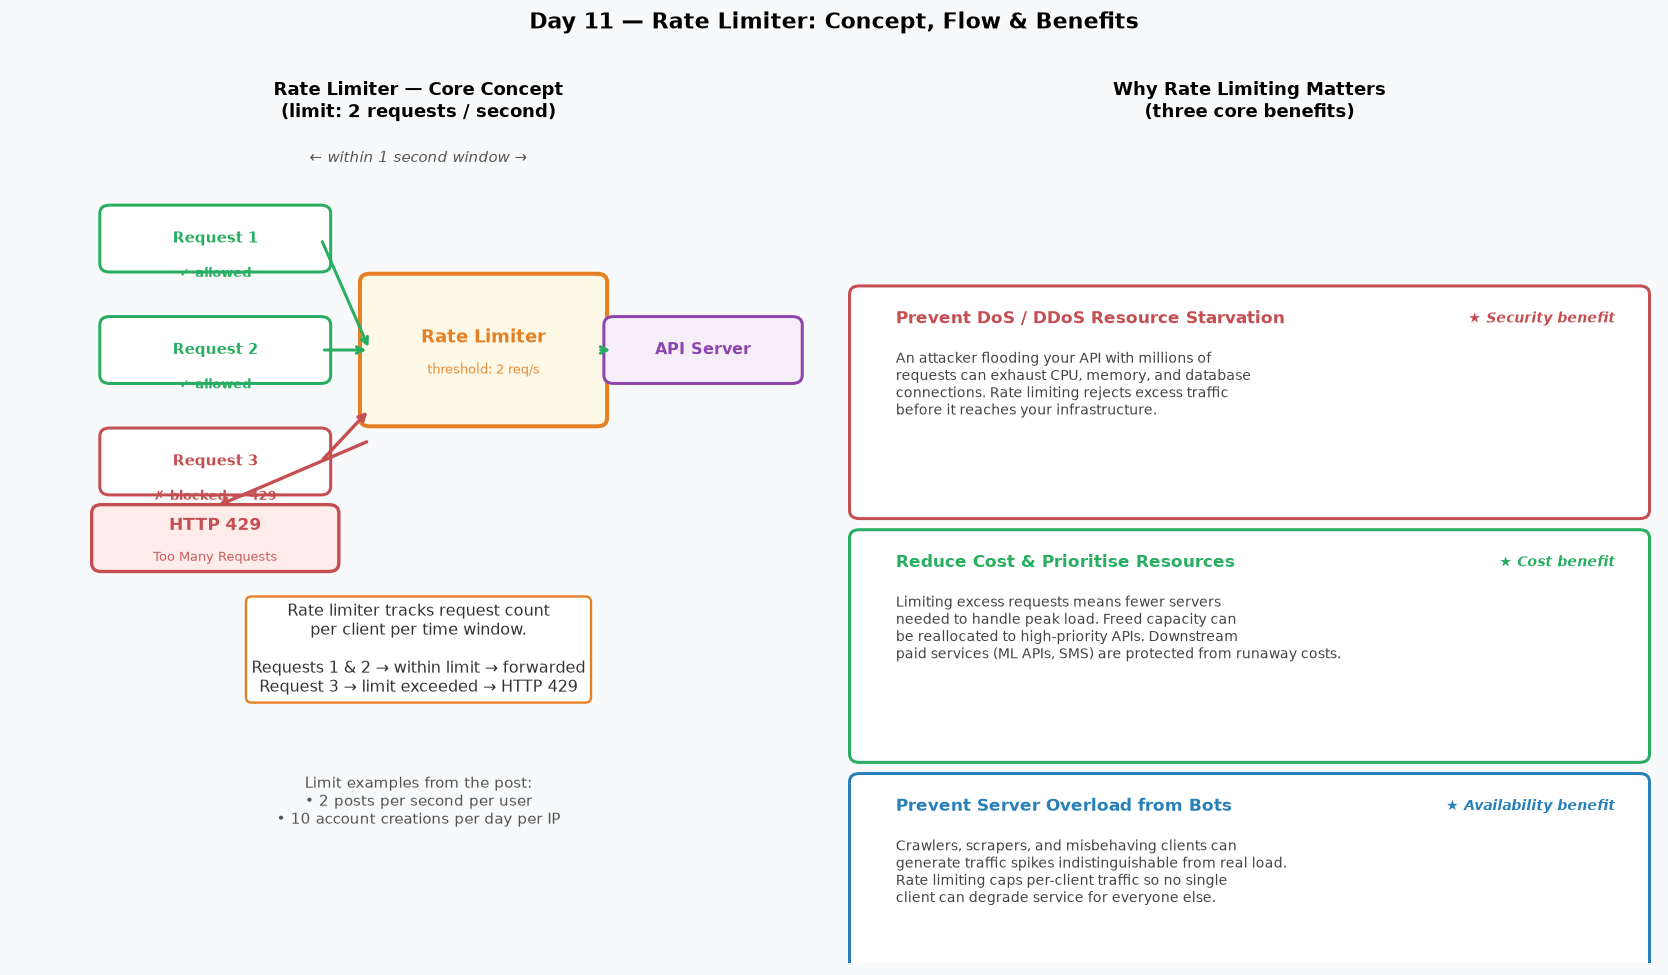

In [2]:
# What is a rate limiter — request flow with allow vs block

fig, axes = plt.subplots(1, 2, figsize=(14, 8))
fig.patch.set_facecolor(C_GRAY)

def rbox(ax, x, y, w, h, label, color, bg='white', sub='', fs=9.5, lw=1.8):
    r = FancyBboxPatch((x - w/2, y - h/2), w, h,
                       boxstyle='round,pad=0.12',
                       facecolor=bg, edgecolor=color, lw=lw)
    ax.add_patch(r)
    ax.text(x, y + (0.18 if sub else 0), label,
            ha='center', va='center', fontsize=fs,
            fontweight='bold', color=color)
    if sub:
        ax.text(x, y - 0.28, sub, ha='center', va='center',
                fontsize=7.5, color=color, alpha=0.9)

def arr(ax, x1, y1, x2, y2, label='', color='#555', lw=1.8, style='->', ls='solid'):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle=style, color=color, lw=lw,
                                linestyle=ls))
    if label:
        mx, my = (x1+x2)/2 + 0.15, (y1+y2)/2 + 0.12
        ax.text(mx, my, label, ha='left', va='center', fontsize=8.5,
                color=color, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.1', facecolor='white',
                          edgecolor=color, lw=0.7, alpha=0.9))

# ── Left: rate limiter concept with allow / block ─────────────────────────────
ax = axes[0]
ax.set_xlim(0, 10); ax.set_ylim(0, 12)
ax.axis('off'); ax.set_facecolor(C_GRAY)
ax.set_title('Rate Limiter — Core Concept\n(limit: 2 requests / second)',
             fontsize=11, fontweight='bold')

# Timeline marker
ax.text(5.0, 11.5, '← within 1 second window →', ha='center',
        fontsize=9, color='#555', fontstyle='italic')

# Three requests from client
req_data = [
    (2.5, 10.4, 'Request 1', C_ALLOW, '✓ allowed'),
    (2.5,  8.8, 'Request 2', C_ALLOW, '✓ allowed'),
    (2.5,  7.2, 'Request 3', C_BLOCK, '✗ blocked — 429'),
]
for rx, ry, rlbl, col, status in req_data:
    rbox(ax, rx, ry, 2.6, 0.72, rlbl, col, bg='white', fs=9)
    ax.text(rx, ry - 0.55, status, ha='center', fontsize=8,
            color=col, fontweight='bold')

# Rate limiter box
rbox(ax, 5.8, 8.8, 2.8, 1.95, 'Rate Limiter', C_RL,
     bg='#FEF9E7', sub='threshold: 2 req/s', fs=10.5, lw=2.4)

# Arrows: req 1 and 2 through limiter → server
for ry, col in [(10.4, C_ALLOW), (8.8, C_ALLOW)]:
    arr(ax, 3.8, ry, 4.4, 8.8, '', col, lw=1.8)

# Req 3 → rate limiter → blocked back to client
arr(ax, 3.8, 7.2, 4.4, 7.95, '', C_BLOCK, lw=2.0)

# Server
rbox(ax, 8.5, 8.8, 2.2, 0.72, 'API Server', C_SERVER,
     bg='#F5EEF8', fs=9.5)
arr(ax, 7.2, 8.8, 7.4, 8.8, '', C_ALLOW, lw=1.8)

# Block return
ax.annotate('', xy=(2.5, 6.55), xytext=(4.4, 7.5),
            arrowprops=dict(arrowstyle='->', color=C_BLOCK, lw=2.0))
rbox(ax, 2.5, 6.1, 2.8, 0.72, 'HTTP 429', C_BLOCK,
     bg='#FDECEA', sub='Too Many Requests', fs=10, lw=2.0)

# Threshold explanation
ax.text(5.0, 4.5,
        'Rate limiter tracks request count\nper client per time window.\n\n'
        'Requests 1 & 2 → within limit → forwarded\n'
        'Request 3 → limit exceeded → HTTP 429',
        ha='center', va='center', fontsize=9.5, color='#333',
        bbox=dict(boxstyle='round,pad=0.35', facecolor='white',
                  edgecolor=C_RL, lw=1.4))

ax.text(5.0, 2.0,
        'Limit examples from the post:\n'
        '• 2 posts per second per user\n'
        '• 10 account creations per day per IP',
        ha='center', fontsize=9, color='#555')

# ── Right: benefits of rate limiting ──────────────────────────────────────────
ax = axes[1]
ax.set_xlim(0, 10); ax.set_ylim(0, 12)
ax.axis('off'); ax.set_facecolor(C_GRAY)
ax.set_title('Why Rate Limiting Matters\n(three core benefits)',
             fontsize=11, fontweight='bold')

benefits = [
    (C_BLOCK,
     'Prevent DoS / DDoS Resource Starvation',
     'An attacker flooding your API with millions of\n'
     'requests can exhaust CPU, memory, and database\n'
     'connections. Rate limiting rejects excess traffic\n'
     'before it reaches your infrastructure.',
     '★ Security benefit'),
    (C_ALLOW,
     'Reduce Cost & Prioritise Resources',
     'Limiting excess requests means fewer servers\n'
     'needed to handle peak load. Freed capacity can\n'
     'be reallocated to high-priority APIs. Downstream\n'
     'paid services (ML APIs, SMS) are protected from runaway costs.',
     '★ Cost benefit'),
    (C_GW,
     'Prevent Server Overload from Bots',
     'Crawlers, scrapers, and misbehaving clients can\n'
     'generate traffic spikes indistinguishable from real load.\n'
     'Rate limiting caps per-client traffic so no single\n'
     'client can degrade service for everyone else.',
     '★ Availability benefit'),
]

y0 = 11.5
for (color, title, body, tag) in benefits:
    y0 -= 3.5
    r = FancyBboxPatch((0.2, y0 - 1.5), 9.6, 3.1,
                       boxstyle='round,pad=0.12',
                       facecolor='white', edgecolor=color, lw=1.8)
    ax.add_patch(r)
    ax.text(0.65, y0 + 1.25, title, ha='left', va='center',
            fontsize=10, fontweight='bold', color=color)
    ax.text(0.65, y0 + 0.3, body, ha='left', va='center',
            fontsize=8.5, color='#444')
    ax.text(9.5, y0 + 1.25, tag, ha='right', va='center',
            fontsize=8.5, color=color, fontstyle='italic', fontweight='bold')

plt.suptitle('Day 11 — Rate Limiter: Concept, Flow & Benefits',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/tmp/sd_day11_concept.png', dpi=130, bbox_inches='tight')
plt.show()


### What these diagrams show

**Left — Core allow/block flow:**  
Three requests arrive within a 1-second window (limit = 2). Requests 1 and 2 (green) pass through the amber rate limiter box to the API server. Request 3 (red) is stopped at the rate limiter — an HTTP 429 response is returned directly to the client. The rate limiter sits between the client and the server, never letting excess traffic touch the backend.

**Right — Three benefit cards:**  
Each card covers one of the three benefits from the post. DoS prevention (red card) shows the security angle; cost reduction (green) shows the economics; bot protection (blue) shows the availability angle.

## 3. Where to Place the Rate Limiter

> "You can implement a rate limiter at either the client or server side. Client is an unreliable place to enforce rate limiting because client requests can easily be forged by malicious actors. Moreover, we might not have control over the client." — Day 11

**Three placement options:**

| Option | Where | Reliable? |
|---|---|---|
| Client-side | In browser/mobile app | ❌ Can be bypassed by attacker tools |
| Server-side | Embedded in each API service | ✓ Reliable, but duplicated per service |
| Middleware / API Gateway | Separate layer before all services | ✓ Best for microservices |

Client-side enforcement is never sufficient as a security control — it can be supplementary (to reduce bandwidth), but the authoritative limit must always live on the server side.

/tmp/ipykernel_354709/3613364196.py:188: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_354709/3613364196.py:189: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('/tmp/sd_day11_placement.png', dpi=130, bbox_inches='tight')


/home/participant/.local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


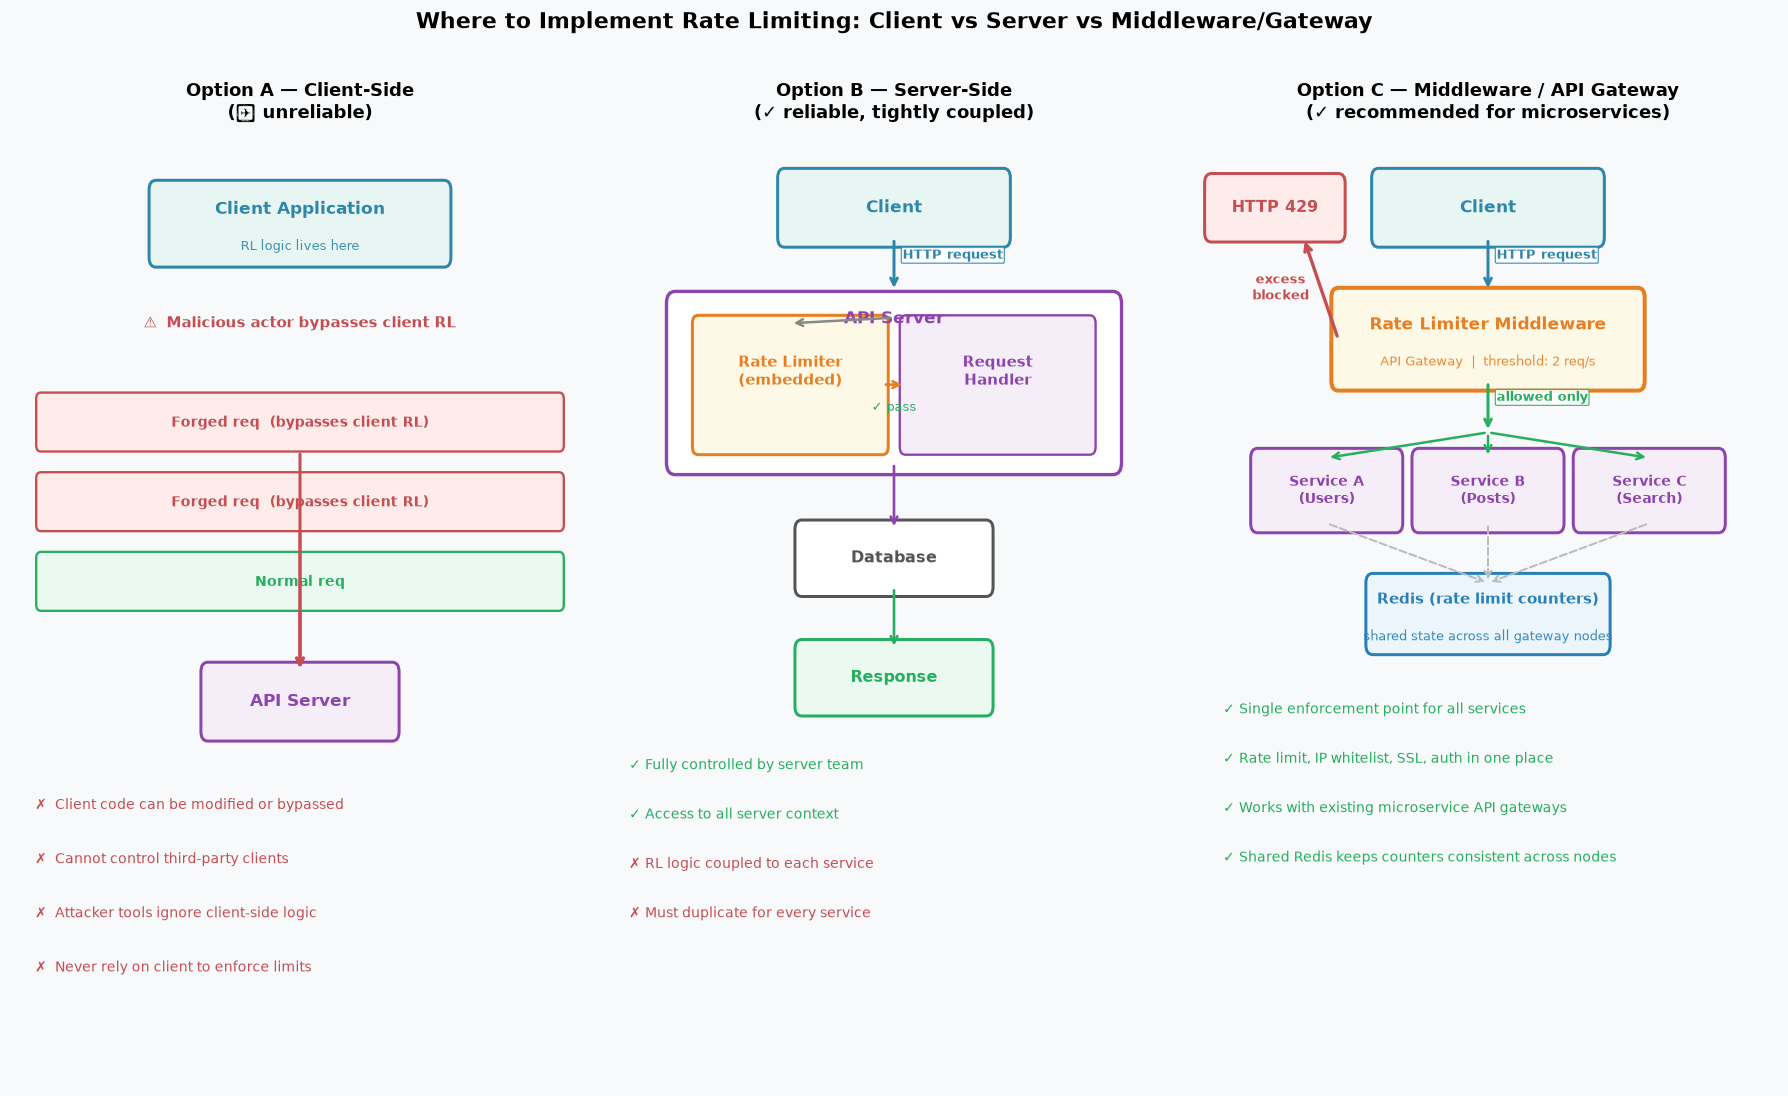

In [3]:
# Where to place the rate limiter: client-side vs server-side vs middleware

fig, axes = plt.subplots(1, 3, figsize=(15, 9))
fig.patch.set_facecolor(C_GRAY)

def rbox(ax, x, y, w, h, label, color, bg='white', sub='', fs=9.5, lw=1.8):
    r = FancyBboxPatch((x - w/2, y - h/2), w, h,
                       boxstyle='round,pad=0.12',
                       facecolor=bg, edgecolor=color, lw=lw)
    ax.add_patch(r)
    ax.text(x, y + (0.18 if sub else 0), label,
            ha='center', va='center', fontsize=fs,
            fontweight='bold', color=color)
    if sub:
        ax.text(x, y - 0.28, sub, ha='center', va='center',
                fontsize=7.5, color=color, alpha=0.9)

def arr(ax, x1, y1, x2, y2, label='', color='#555', lw=1.8):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=color, lw=lw))
    if label:
        mx, my = (x1+x2)/2 + 0.15, (y1+y2)/2 + 0.12
        ax.text(mx, my, label, ha='left', va='center', fontsize=8,
                color=color, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.1', facecolor='white',
                          edgecolor=color, lw=0.7, alpha=0.9))

# ── Panel 1: client-side (unreliable) ─────────────────────────────────────────
ax = axes[0]
ax.set_xlim(0, 10); ax.set_ylim(0, 12)
ax.axis('off'); ax.set_facecolor(C_GRAY)
ax.set_title('Option A — Client-Side\n(❌ unreliable)', fontsize=11, fontweight='bold')

rbox(ax, 5.0, 10.8, 5.0, 0.85, 'Client Application', C_CLIENT,
     bg='#E8F6F3', sub='RL logic lives here', fs=10)

# Attacker forges requests
ax.text(5.0, 9.5, '⚠  Malicious actor bypasses client RL', ha='center',
        fontsize=9, color=C_BLOCK, fontweight='bold')

for i, (lbl, col) in enumerate([
        ('Forged req  (bypasses client RL)', C_BLOCK),
        ('Forged req  (bypasses client RL)', C_BLOCK),
        ('Normal req', C_ALLOW)]):
    ry = 8.3 - i * 1.0
    r = FancyBboxPatch((0.5, ry - 0.28), 9.0, 0.58,
                       boxstyle='round,pad=0.08',
                       facecolor='#FDECEA' if col == C_BLOCK else '#EAFAF1',
                       edgecolor=col, lw=1.4)
    ax.add_patch(r)
    ax.text(5.0, ry, lbl, ha='center', va='center', fontsize=8.5,
            color=col, fontweight='bold')

rbox(ax, 5.0, 4.8, 3.2, 0.75, 'API Server', C_SERVER,
     bg='#F5EEF8', fs=10)

for i in range(3):
    arr(ax, 5.0, 5.95 + (2-i)*1.0, 5.0, 5.18, '', C_BLOCK)

problems = [
    'Client code can be modified or bypassed',
    'Cannot control third-party clients',
    'Attacker tools ignore client-side logic',
    'Never rely on client to enforce limits',
]
y0 = 3.5
for pt in problems:
    ax.text(0.4, y0, f'✗  {pt}', ha='left', va='center',
            fontsize=8.5, color=C_BLOCK)
    y0 -= 0.68

# ── Panel 2: server-side RL in API server ─────────────────────────────────────
ax = axes[1]
ax.set_xlim(0, 10); ax.set_ylim(0, 12)
ax.axis('off'); ax.set_facecolor(C_GRAY)
ax.set_title('Option B — Server-Side\n(✓ reliable, tightly coupled)',
             fontsize=11, fontweight='bold')

rbox(ax, 5.0, 11.0, 3.8, 0.75, 'Client', C_CLIENT,
     bg='#E8F6F3', fs=10)
arr(ax, 5.0, 10.62, 5.0, 9.95, 'HTTP request', C_CLIENT)

# API server with embedded RL
r = FancyBboxPatch((1.2, 7.8), 7.6, 2.0,
                   boxstyle='round,pad=0.15',
                   facecolor='white', edgecolor=C_SERVER, lw=2.0)
ax.add_patch(r)
ax.text(5.0, 9.55, 'API Server', ha='center', fontsize=10,
        fontweight='bold', color=C_SERVER)

# Inner RL box
r2 = FancyBboxPatch((1.6, 8.0), 3.2, 1.55,
                    boxstyle='round,pad=0.1',
                    facecolor='#FEF9E7', edgecolor=C_RL, lw=1.8)
ax.add_patch(r2)
ax.text(3.2, 8.78, 'Rate Limiter\n(embedded)', ha='center', fontsize=9,
        fontweight='bold', color=C_RL)

# Inner handler box
r3 = FancyBboxPatch((5.2, 8.0), 3.2, 1.55,
                    boxstyle='round,pad=0.1',
                    facecolor='#F5EEF8', edgecolor=C_SERVER, lw=1.4)
ax.add_patch(r3)
ax.text(6.8, 8.78, 'Request\nHandler', ha='center', fontsize=9,
        fontweight='bold', color=C_SERVER)

ax.annotate('', xy=(5.2, 8.78), xytext=(4.8, 8.78),
            arrowprops=dict(arrowstyle='->', color=C_RL, lw=1.6))
ax.text(5.0, 8.45, '✓ pass', ha='center', fontsize=8, color=C_ALLOW)

arr(ax, 5.0, 9.62, 3.2, 9.55, '', '#888', lw=1.5)

# Database / Response
rbox(ax, 5.0, 6.6, 3.2, 0.72, 'Database', '#555',
     bg='white', fs=9.5)
arr(ax, 5.0, 7.8, 5.0, 6.96, '', C_SERVER, lw=1.6)

rbox(ax, 5.0, 5.1, 3.2, 0.72, 'Response', C_ALLOW,
     bg='#EAFAF1', fs=9.5)
arr(ax, 5.0, 6.24, 5.0, 5.46, '', C_ALLOW, lw=1.6)

pros_cons = [
    (C_ALLOW, '✓ Fully controlled by server team'),
    (C_ALLOW, '✓ Access to all server context'),
    (C_BLOCK, '✗ RL logic coupled to each service'),
    (C_BLOCK, '✗ Must duplicate for every service'),
]
y0 = 4.0
for col, txt in pros_cons:
    ax.text(0.4, y0, txt, ha='left', va='center', fontsize=8.5, color=col)
    y0 -= 0.62

# ── Panel 3: middleware / API gateway ─────────────────────────────────────────
ax = axes[2]
ax.set_xlim(0, 10); ax.set_ylim(0, 12)
ax.axis('off'); ax.set_facecolor(C_GRAY)
ax.set_title('Option C — Middleware / API Gateway\n(✓ recommended for microservices)',
             fontsize=11, fontweight='bold')

rbox(ax, 5.0, 11.0, 3.8, 0.75, 'Client', C_CLIENT,
     bg='#E8F6F3', fs=10)
arr(ax, 5.0, 10.62, 5.0, 9.95, 'HTTP request', C_CLIENT)

# Middleware / gateway
rbox(ax, 5.0, 9.35, 5.2, 1.05, 'Rate Limiter Middleware', C_RL,
     bg='#FEF9E7', sub='API Gateway  |  threshold: 2 req/s', fs=10, lw=2.4)

# HTTP 429 back to client
ax.annotate('', xy=(1.8, 10.62), xytext=(2.4, 9.35),
            arrowprops=dict(arrowstyle='->', color=C_BLOCK, lw=2.0))
rbox(ax, 1.3, 11.0, 2.2, 0.62, 'HTTP 429', C_BLOCK,
     bg='#FDECEA', fs=9.5, lw=1.8)
ax.text(1.4, 9.85, 'excess\nblocked', ha='center', fontsize=8,
        color=C_BLOCK, fontweight='bold')

arr(ax, 5.0, 8.82, 5.0, 8.18, 'allowed only', C_ALLOW, lw=1.8)

# Three backend services
svc_data = [(2.2, 'Service A\n(Users)'),
            (5.0, 'Service B\n(Posts)'),
            (7.8, 'Service C\n(Search)')]
for sx, slbl in svc_data:
    rbox(ax, sx, 7.45, 2.4, 0.82, slbl, C_SERVER,
         bg='#F5EEF8', fs=8.5)
    arr(ax, 5.0, 8.18, sx, 7.86, '', C_ALLOW, lw=1.5)

# Shared cache for RL counters
rbox(ax, 5.0, 5.9, 4.0, 0.78, 'Redis (rate limit counters)', C_GW,
     bg='#EBF5FB', sub='shared state across all gateway nodes', fs=9, lw=1.8)
for sx, _ in svc_data:
    ax.annotate('', xy=(5.0, 6.29), xytext=(sx, 7.04),
                arrowprops=dict(arrowstyle='->', color='#bbb', lw=1.2,
                                linestyle='dashed'))

gw_features = [
    '✓ Single enforcement point for all services',
    '✓ Rate limit, IP whitelist, SSL, auth in one place',
    '✓ Works with existing microservice API gateways',
    '✓ Shared Redis keeps counters consistent across nodes',
]
y0 = 4.7
for pt in gw_features:
    ax.text(0.4, y0, pt, ha='left', va='center', fontsize=8.5, color=C_ALLOW)
    y0 -= 0.62

plt.suptitle('Where to Implement Rate Limiting: Client vs Server vs Middleware/Gateway',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/tmp/sd_day11_placement.png', dpi=130, bbox_inches='tight')
plt.show()


### What these diagrams show

**Left — Client-side (Option A):**  
Forged requests bypass the client-side rate limit entirely — they flow directly to the API server. The red X marks it as unreliable. Four problem bullets explain why client enforcement is insufficient.

**Middle — Server-side (Option B):**  
The rate limiter is embedded inside the API server process. An inner RL box sits alongside the request handler within the same server rectangle. Reliable, but the RL logic must be duplicated for every service.

**Right — Middleware / API Gateway (Option C):**  
A single rate limiter middleware layer intercepts all traffic before it reaches any of the three backend services. Excess requests are returned as HTTP 429. A Redis store (dashed arrows) holds the counters shared across all gateway nodes. Four green ticks show the benefits of centralised enforcement.

## 4. API Gateway Rate Limiter & HTTP 429 Exception Handling

> "Rate limiter middleware throttles the HTTP request and returns status code 429 — Too Many Requests to the user. In cloud microservices, rate limiting is usually implemented within a component called API Gateway." — Day 11

**The standard HTTP response for rate limiting is 429 Too Many Requests.**

Three headers are expected by compliant clients:
- `X-RateLimit-Limit` — the total quota for the current window
- `X-RateLimit-Remaining` — requests left before the next block
- `Retry-After` — seconds to wait before retrying (per RFC 6585)

Well-designed clients use these headers to self-throttle before hitting the limit, reducing unnecessary 429 traffic.

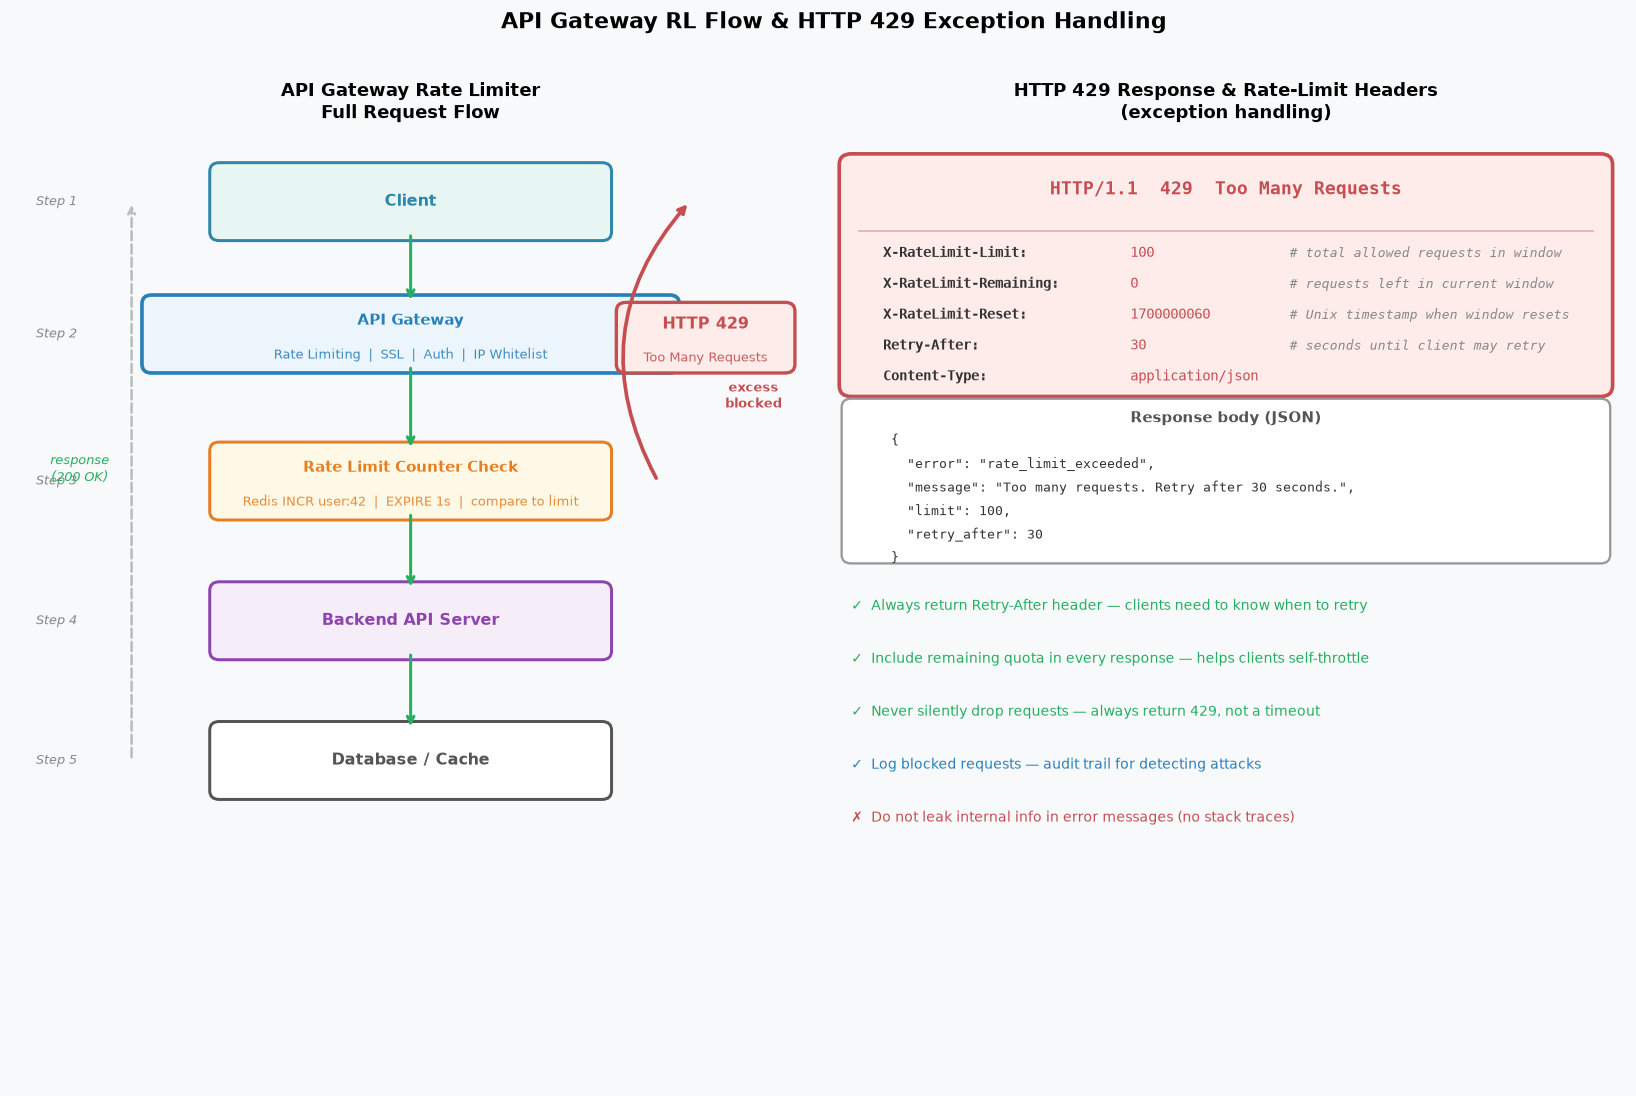

In [4]:
# API Gateway as rate limiter: detailed flow with HTTP 429 and headers

fig, axes = plt.subplots(1, 2, figsize=(14, 9))
fig.patch.set_facecolor(C_GRAY)

def rbox(ax, x, y, w, h, label, color, bg='white', sub='', fs=9.5, lw=1.8):
    r = FancyBboxPatch((x - w/2, y - h/2), w, h,
                       boxstyle='round,pad=0.12',
                       facecolor=bg, edgecolor=color, lw=lw)
    ax.add_patch(r)
    ax.text(x, y + (0.18 if sub else 0), label,
            ha='center', va='center', fontsize=fs,
            fontweight='bold', color=color)
    if sub:
        ax.text(x, y - 0.28, sub, ha='center', va='center',
                fontsize=7.5, color=color, alpha=0.9)

def arr(ax, x1, y1, x2, y2, label='', color='#555', lw=1.8):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=color, lw=lw))
    if label:
        mx, my = (x1+x2)/2 + 0.15, (y1+y2)/2 + 0.12
        ax.text(mx, my, label, ha='left', va='center', fontsize=8.5,
                color=color, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.1', facecolor='white',
                          edgecolor=color, lw=0.7, alpha=0.9))

# ── Left: full request flow through API gateway RL ────────────────────────────
ax = axes[0]
ax.set_xlim(0, 10); ax.set_ylim(0, 13)
ax.axis('off'); ax.set_facecolor(C_GRAY)
ax.set_title('API Gateway Rate Limiter\nFull Request Flow',
             fontsize=11, fontweight='bold')

# Numbered steps
steps = [
    (5.0, 12.0, 'Client',                   C_CLIENT, '#E8F6F3', ''),
    (5.0, 10.2, 'API Gateway',              C_GW,     '#EBF5FB',
     'Rate Limiting  |  SSL  |  Auth  |  IP Whitelist'),
    (5.0,  8.2, 'Rate Limit Counter Check', C_RL,     '#FEF9E7',
     'Redis INCR user:42  |  EXPIRE 1s  |  compare to limit'),
    (5.0,  6.3, 'Backend API Server',       C_SERVER, '#F5EEF8', ''),
    (5.0,  4.4, 'Database / Cache',         '#555',   'white',   ''),
]

for i, (sx, sy, lbl, col, bg, sub) in enumerate(steps):
    rbox(ax, sx, sy, 6.5 if i == 1 else 4.8, 0.82, lbl, col,
         bg=bg, sub=sub, fs=9.5 if not sub else 9, lw=2.2 if i == 1 else 1.8)
    ax.text(0.3, sy, f'Step {i+1}', ha='left', va='center',
            fontsize=8, color='#888', fontstyle='italic')

# Downward happy path arrows
for i in range(len(steps) - 1):
    arr(ax, 5.0, steps[i][1] - 0.42, 5.0, steps[i+1][1] + 0.42, '', C_ALLOW, lw=1.8)

# Block path: counter check → HTTP 429 back to client
ax.annotate('', xy=(8.5, 12.0), xytext=(8.1, 8.2),
            arrowprops=dict(arrowstyle='->', color=C_BLOCK, lw=2.2,
                            connectionstyle='arc3,rad=-0.35'))
rbox(ax, 8.7, 10.15, 2.0, 0.72, 'HTTP 429', C_BLOCK,
     bg='#FDECEA', sub='Too Many Requests', fs=9.5, lw=2.0)
ax.text(9.3, 9.2, 'excess\nblocked', ha='center', fontsize=8,
        color=C_BLOCK, fontweight='bold')

# Response path back
ax.annotate('', xy=(1.5, 12.0), xytext=(1.5, 4.4),
            arrowprops=dict(arrowstyle='->', color='#bbb', lw=1.5,
                            linestyle='dashed'))
ax.text(0.85, 8.2, 'response\n(200 OK)', ha='center', fontsize=8,
        color=C_ALLOW, fontstyle='italic')

# ── Right: HTTP 429 response and headers ──────────────────────────────────────
ax = axes[1]
ax.set_xlim(0, 10); ax.set_ylim(0, 13)
ax.axis('off'); ax.set_facecolor(C_GRAY)
ax.set_title('HTTP 429 Response & Rate-Limit Headers\n(exception handling)',
             fontsize=11, fontweight='bold')

# HTTP 429 block
r = FancyBboxPatch((0.3, 9.5), 9.4, 3.0,
                   boxstyle='round,pad=0.15',
                   facecolor='#FDECEA', edgecolor=C_BLOCK, lw=2.2)
ax.add_patch(r)
ax.text(5.0, 12.1, 'HTTP/1.1  429  Too Many Requests',
        ha='center', fontsize=11, fontweight='bold', color=C_BLOCK,
        family='monospace')
ax.axhline(11.6, xmin=0.04, xmax=0.96, color=C_BLOCK, lw=1.0, alpha=0.4)

headers = [
    ('X-RateLimit-Limit:',      '100',           'total allowed requests in window'),
    ('X-RateLimit-Remaining:',  '0',             'requests left in current window'),
    ('X-RateLimit-Reset:',      '1700000060',    'Unix timestamp when window resets'),
    ('Retry-After:',            '30',            'seconds until client may retry'),
    ('Content-Type:',           'application/json', ''),
]
y0 = 11.3
for hdr, val, comment in headers:
    ax.text(0.7, y0, hdr, ha='left', va='center', fontsize=8.5,
            color='#333', fontweight='bold', family='monospace')
    ax.text(3.8, y0, val, ha='left', va='center', fontsize=8.5,
            color=C_BLOCK, family='monospace')
    if comment:
        ax.text(5.8, y0, f'# {comment}', ha='left', va='center',
                fontsize=7.5, color='#888', fontstyle='italic', family='monospace')
    y0 -= 0.42

# JSON body
r2 = FancyBboxPatch((0.3, 7.2), 9.4, 2.0,
                    boxstyle='round,pad=0.12',
                    facecolor='white', edgecolor='#999', lw=1.4)
ax.add_patch(r2)
ax.text(5.0, 9.0, 'Response body (JSON)', ha='center', fontsize=9,
        fontweight='bold', color='#555')
json_lines = [
    '{',
    '  "error": "rate_limit_exceeded",',
    '  "message": "Too many requests. Retry after 30 seconds.",',
    '  "limit": 100,',
    '  "retry_after": 30',
    '}',
]
y0 = 8.75
for line in json_lines:
    ax.text(0.8, y0, line, ha='left', va='center', fontsize=8,
            color='#333', family='monospace')
    y0 -= 0.32

# Good practices
good = [
    (C_ALLOW, 'Always return Retry-After header — clients need to know when to retry'),
    (C_ALLOW, 'Include remaining quota in every response — helps clients self-throttle'),
    (C_ALLOW, 'Never silently drop requests — always return 429, not a timeout'),
    (C_GW,    'Log blocked requests — audit trail for detecting attacks'),
    (C_BLOCK, 'Do not leak internal info in error messages (no stack traces)'),
]
y0 = 6.5
for col, txt in good:
    ax.text(0.3, y0, f'{"✓" if col != C_BLOCK else "✗"}  {txt}',
            ha='left', va='center', fontsize=8.5, color=col)
    y0 -= 0.72

plt.suptitle('API Gateway RL Flow & HTTP 429 Exception Handling',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/tmp/sd_day11_gateway.png', dpi=130, bbox_inches='tight')
plt.show()


### What these diagrams show

**Left — Full request flow through API Gateway:**  
Five numbered steps from client to database. The API gateway (step 2) handles rate limiting, SSL, auth, and IP whitelisting. The rate limit counter check (step 3) queries Redis atomically. A curved red arrow on the right shows the early return path for blocked requests — they exit at the counter check step and return HTTP 429, never reaching the backend. A dashed response path on the left shows the 200 OK path for allowed requests.

**Right — HTTP 429 response anatomy:**  
A complete HTTP 429 response block shows the five rate-limit headers with inline comments explaining each field. A JSON body box shows the structured error response. Five practice rules at the bottom cover the 'how to do exception handling correctly' guidance from the post.

## 5. Distributed Rate Limiting

> "Distributed rate limiting. The rate limiter can be shared across multiple servers or processes." — Day 11 Requirements

**The distributed challenge:**
When multiple gateway nodes sit behind a load balancer, each node may see only a fraction of a client's requests. A local in-process counter on each node will show a low count even when the global rate has been exceeded.

**Example:** Limit = 5 req/s. Client sends 9 requests distributed across 3 gateways. Each gateway sees only 3 — all pass. Actual rate = 9 req/s. Limit violated by 80%.

**The solution: centralised Redis counter with atomic operations.**
```
REDIS> INCR rate_limit:user42
REDIS> EXPIRE rate_limit:user42 1
```
The `INCR` command is atomic — even under concurrent gateway requests, the counter is always accurate. `EXPIRE` resets the window automatically.

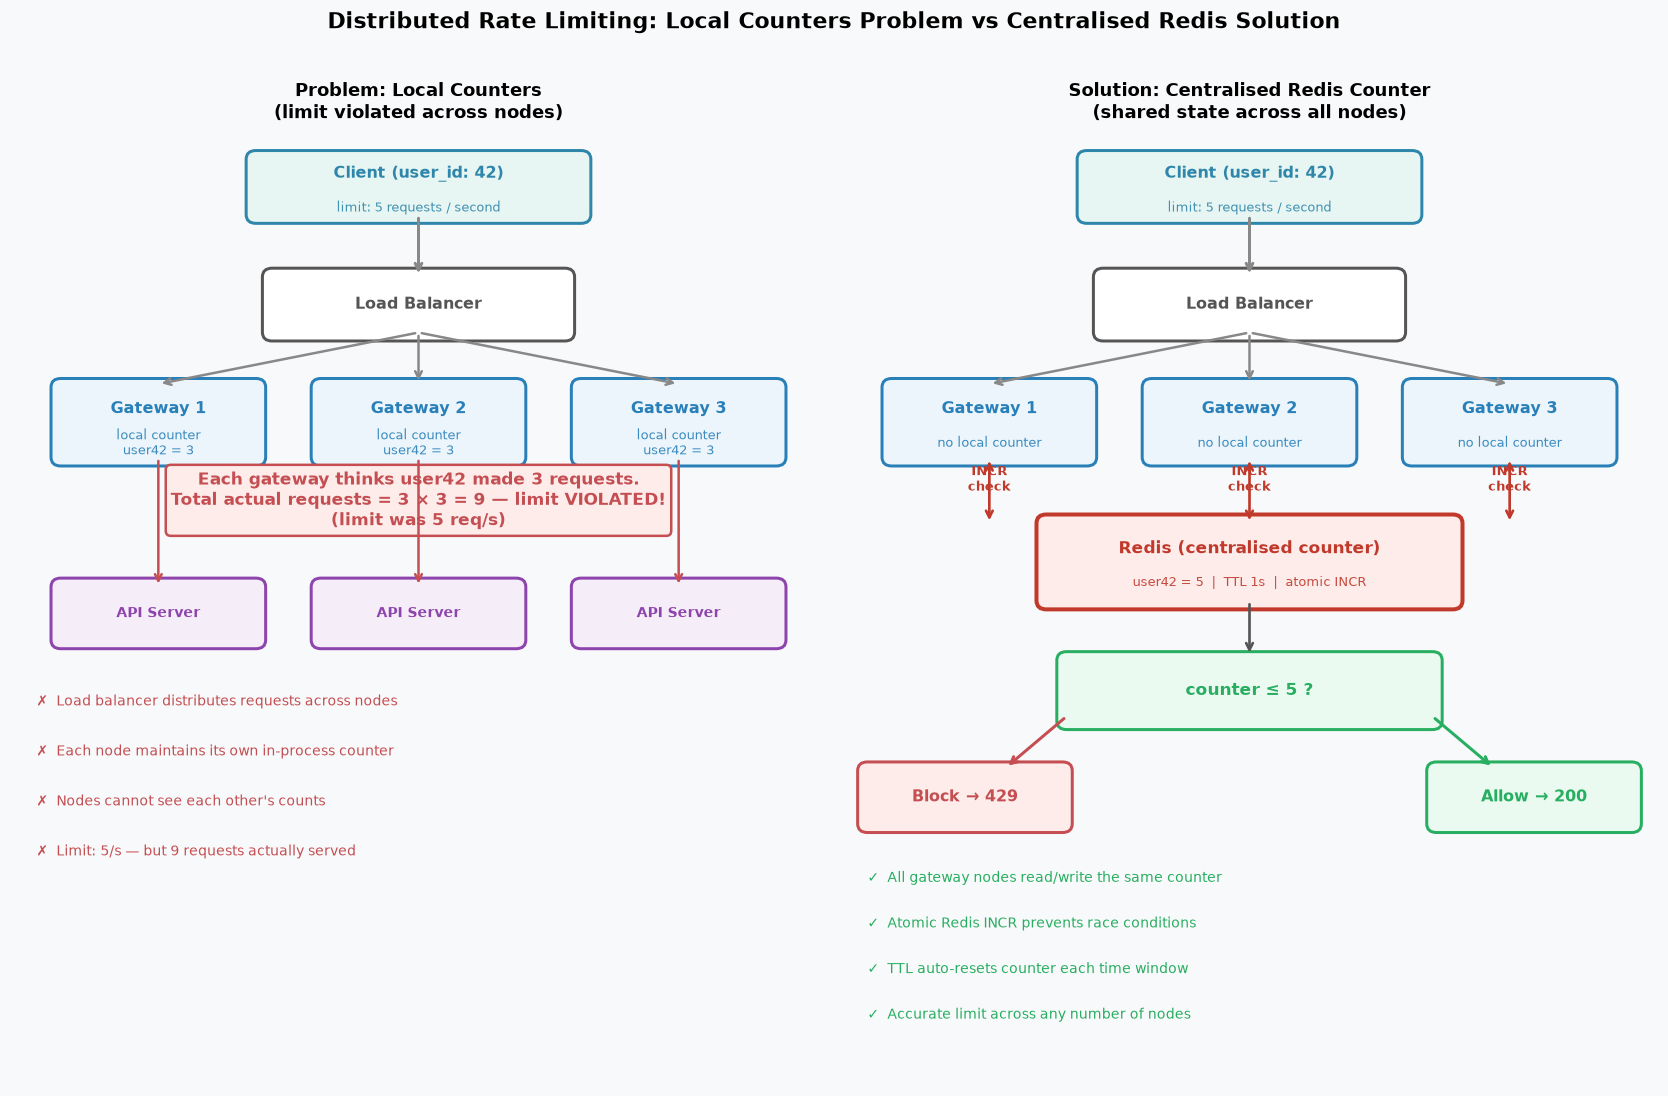

In [5]:
# Distributed rate limiting: the challenge of multiple gateway nodes

fig, axes = plt.subplots(1, 2, figsize=(14, 9))
fig.patch.set_facecolor(C_GRAY)

def rbox(ax, x, y, w, h, label, color, bg='white', sub='', fs=9.5, lw=1.8):
    r = FancyBboxPatch((x - w/2, y - h/2), w, h,
                       boxstyle='round,pad=0.12',
                       facecolor=bg, edgecolor=color, lw=lw)
    ax.add_patch(r)
    ax.text(x, y + (0.18 if sub else 0), label,
            ha='center', va='center', fontsize=fs,
            fontweight='bold', color=color)
    if sub:
        ax.text(x, y - 0.28, sub, ha='center', va='center',
                fontsize=7.5, color=color, alpha=0.9)

def arr(ax, x1, y1, x2, y2, label='', color='#555', lw=1.8):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=color, lw=lw))
    if label:
        mx, my = (x1+x2)/2 + 0.15, (y1+y2)/2 + 0.12
        ax.text(mx, my, label, ha='left', va='center', fontsize=8.5,
                color=color, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.1', facecolor='white',
                          edgecolor=color, lw=0.7, alpha=0.9))

# ── Left: naive local counters — the problem ──────────────────────────────────
ax = axes[0]
ax.set_xlim(0, 10); ax.set_ylim(0, 13)
ax.axis('off'); ax.set_facecolor(C_GRAY)
ax.set_title('Problem: Local Counters\n(limit violated across nodes)',
             fontsize=11, fontweight='bold')

rbox(ax, 5.0, 12.2, 4.0, 0.75, 'Client (user_id: 42)', C_CLIENT,
     bg='#E8F6F3', sub='limit: 5 requests / second', fs=9.5)

# Load balancer
rbox(ax, 5.0, 10.6, 3.6, 0.75, 'Load Balancer', '#555',
     bg='white', fs=9.5)
arr(ax, 5.0, 11.82, 5.0, 10.98, '', '#888')

# Three gateway nodes with LOCAL counters
node_data = [
    (1.8, 'Gateway 1', 'local counter\nuser42 = 3', C_GW),
    (5.0, 'Gateway 2', 'local counter\nuser42 = 3', C_GW),
    (8.2, 'Gateway 3', 'local counter\nuser42 = 3', C_GW),
]
for nx, nlbl, nsub, col in node_data:
    arr(ax, 5.0, 10.22, nx, 9.52, '', '#888', lw=1.5)
    rbox(ax, nx, 9.0, 2.4, 0.95, nlbl, col,
         bg='#EBF5FB', sub=nsub, fs=9.5, lw=1.8)

# Annotation showing violation
ax.text(5.0, 7.6,
        'Each gateway thinks user42 made 3 requests.\n'
        'Total actual requests = 3 × 3 = 9 — limit VIOLATED!\n'
        '(limit was 5 req/s)',
        ha='center', fontsize=10, color=C_BLOCK, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#FDECEA',
                  edgecolor=C_BLOCK, lw=1.5))

# Three backend servers pass through
for nx, _, _, _ in node_data:
    rbox(ax, nx, 6.4, 2.4, 0.72, 'API Server', C_SERVER,
         bg='#F5EEF8', fs=8.5)
    arr(ax, nx, 8.52, nx, 6.76, '', C_BLOCK, lw=1.5)

reasons = [
    'Load balancer distributes requests across nodes',
    'Each node maintains its own in-process counter',
    'Nodes cannot see each other\'s counts',
    'Limit: 5/s — but 9 requests actually served',
]
y0 = 5.2
for pt in reasons:
    ax.text(0.3, y0, f'✗  {pt}', ha='left', va='center',
            fontsize=8.5, color=C_BLOCK)
    y0 -= 0.68

# ── Right: shared Redis counter — the solution ────────────────────────────────
ax = axes[1]
ax.set_xlim(0, 10); ax.set_ylim(0, 13)
ax.axis('off'); ax.set_facecolor(C_GRAY)
ax.set_title('Solution: Centralised Redis Counter\n(shared state across all nodes)',
             fontsize=11, fontweight='bold')

rbox(ax, 5.0, 12.2, 4.0, 0.75, 'Client (user_id: 42)', C_CLIENT,
     bg='#E8F6F3', sub='limit: 5 requests / second', fs=9.5)

rbox(ax, 5.0, 10.6, 3.6, 0.75, 'Load Balancer', '#555',
     bg='white', fs=9.5)
arr(ax, 5.0, 11.82, 5.0, 10.98, '', '#888')

for nx, nlbl, _, col in node_data:
    arr(ax, 5.0, 10.22, nx, 9.52, '', '#888', lw=1.5)
    rbox(ax, nx, 9.0, 2.4, 0.95, nlbl, col,
         bg='#EBF5FB', sub='no local counter', fs=9.5, lw=1.8)

# Shared Redis
rbox(ax, 5.0, 7.1, 5.0, 1.05, 'Redis (centralised counter)', '#C0392B',
     bg='#FDECEA', sub='user42 = 5  |  TTL 1s  |  atomic INCR', fs=10, lw=2.4)

for nx, _, _, _ in node_data:
    ax.annotate('', xy=(nx, 7.62), xytext=(nx, 8.52),
                arrowprops=dict(arrowstyle='<->', color='#C0392B', lw=1.6))
    ax.text(nx, 8.07, 'INCR\ncheck', ha='center', fontsize=7.5,
            color='#C0392B', fontweight='bold')

# If <= 5: pass; if > 5: block
arr(ax, 5.0, 6.57, 5.0, 5.82, '', '#555', lw=1.6)

# Decision
rbox(ax, 5.0, 5.35, 4.5, 0.82, 'counter ≤ 5 ?', C_ALLOW,
     bg='#EAFAF1', sub='', fs=10, lw=1.8)

# Pass path
ax.annotate('', xy=(8.0, 4.3), xytext=(7.25, 5.0),
            arrowprops=dict(arrowstyle='->', color=C_ALLOW, lw=1.8))
rbox(ax, 8.5, 3.9, 2.4, 0.72, 'Allow → 200', C_ALLOW,
     bg='#EAFAF1', fs=9.5)

# Block path
ax.annotate('', xy=(2.0, 4.3), xytext=(2.75, 5.0),
            arrowprops=dict(arrowstyle='->', color=C_BLOCK, lw=1.8))
rbox(ax, 1.5, 3.9, 2.4, 0.72, 'Block → 429', C_BLOCK,
     bg='#FDECEA', fs=9.5)

benefits = [
    'All gateway nodes read/write the same counter',
    'Atomic Redis INCR prevents race conditions',
    'TTL auto-resets counter each time window',
    'Accurate limit across any number of nodes',
]
y0 = 2.8
for pt in benefits:
    ax.text(0.3, y0, f'✓  {pt}', ha='left', va='center',
            fontsize=8.5, color=C_ALLOW)
    y0 -= 0.62

plt.suptitle('Distributed Rate Limiting: Local Counters Problem vs Centralised Redis Solution',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/tmp/sd_day11_distributed.png', dpi=130, bbox_inches='tight')
plt.show()


### What these diagrams show

**Left — Local counters (the problem):**  
Three gateway nodes each show `user42 = 3` in their local counters. The annotation calculates `3 × 3 = 9` total requests against a limit of 5. All requests reach the API servers because no single node knows the true total. Red bullets explain the root cause.

**Right — Centralised Redis (the solution):**  
The same three gateway nodes now have no local counter. Instead, they each connect to a central Redis node (red box, `user42 = 5`). Bi-directional INCR/check arrows between each gateway and Redis show the atomic read-increment-compare loop. A decision diamond below Redis routes to either HTTP 200 (allow) or HTTP 429 (block) based on the counter value.

## 6. Design Requirements → Architecture Decisions

A complete rate limiter must satisfy six requirements. Each maps to a specific architecture or implementation decision:

| Requirement | Architecture Decision |
|---|---|
| Accurate limiting | Redis atomic INCR + per-user and per-IP keys |
| Low latency | Sub-ms Redis in-memory lookup on critical path |
| Low memory | INCR + EXPIRE: one integer per key, auto-evicted |
| Distributed | Shared Redis cluster — no node-local state |
| Exception handling | HTTP 429 + Retry-After + rate-limit headers |
| Fault tolerance | Redis Sentinel HA + fail-open circuit breaker |

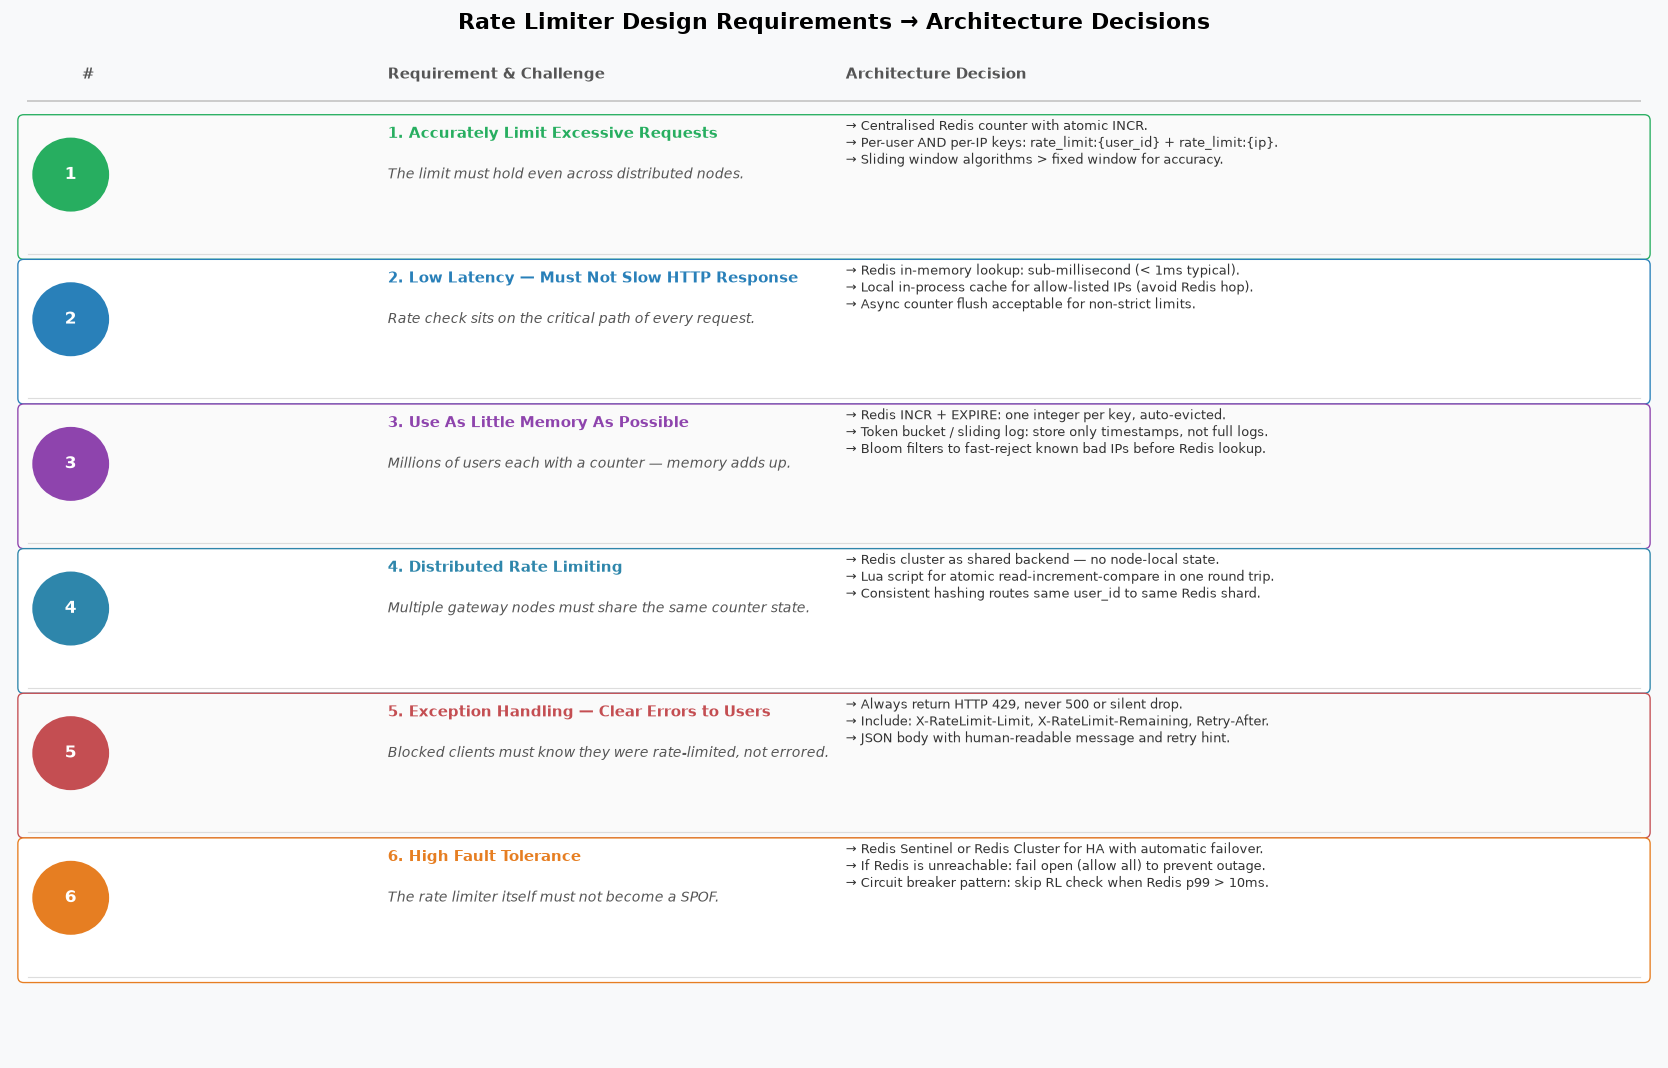

In [6]:
# Requirements deep-dive: the 6 design requirements mapped to architecture

fig, ax = plt.subplots(figsize=(14, 9))
fig.patch.set_facecolor(C_GRAY)
ax.set_xlim(0, 14); ax.set_ylim(0, 9)
ax.axis('off'); ax.set_facecolor(C_GRAY)
ax.set_title('Rate Limiter Design Requirements → Architecture Decisions',
             fontsize=13, fontweight='bold')

requirements = [
    (C_ALLOW,
     '1. Accurately Limit Excessive Requests',
     'The limit must hold even across distributed nodes.',
     '→ Centralised Redis counter with atomic INCR.\n'
     '→ Per-user AND per-IP keys: rate_limit:{user_id} + rate_limit:{ip}.\n'
     '→ Sliding window algorithms > fixed window for accuracy.'),

    (C_GW,
     '2. Low Latency — Must Not Slow HTTP Response',
     'Rate check sits on the critical path of every request.',
     '→ Redis in-memory lookup: sub-millisecond (< 1ms typical).\n'
     '→ Local in-process cache for allow-listed IPs (avoid Redis hop).\n'
     '→ Async counter flush acceptable for non-strict limits.'),

    (C_SHARD if False else '#8E44AD',
     '3. Use As Little Memory As Possible',
     'Millions of users each with a counter — memory adds up.',
     '→ Redis INCR + EXPIRE: one integer per key, auto-evicted.\n'
     '→ Token bucket / sliding log: store only timestamps, not full logs.\n'
     '→ Bloom filters to fast-reject known bad IPs before Redis lookup.'),

    (C_CLIENT,
     '4. Distributed Rate Limiting',
     'Multiple gateway nodes must share the same counter state.',
     '→ Redis cluster as shared backend — no node-local state.\n'
     '→ Lua script for atomic read-increment-compare in one round trip.\n'
     '→ Consistent hashing routes same user_id to same Redis shard.'),

    (C_BLOCK,
     '5. Exception Handling — Clear Errors to Users',
     'Blocked clients must know they were rate-limited, not errored.',
     '→ Always return HTTP 429, never 500 or silent drop.\n'
     '→ Include: X-RateLimit-Limit, X-RateLimit-Remaining, Retry-After.\n'
     '→ JSON body with human-readable message and retry hint.'),

    (C_RL,
     '6. High Fault Tolerance',
     'The rate limiter itself must not become a SPOF.',
     '→ Redis Sentinel or Redis Cluster for HA with automatic failover.\n'
     '→ If Redis is unreachable: fail open (allow all) to prevent outage.\n'
     '→ Circuit breaker pattern: skip RL check when Redis p99 > 10ms.'),
]

col_x = [0.15, 3.1, 7.0]   # req number, title+problem, architecture

# Header
ax.text(col_x[0] + 0.5, 8.65, '#', ha='center', fontsize=9,
        fontweight='bold', color='#555')
ax.text(col_x[1] + 0.1, 8.65, 'Requirement & Challenge', ha='left', fontsize=9,
        fontweight='bold', color='#555')
ax.text(col_x[2] + 0.1, 8.65, 'Architecture Decision', ha='left', fontsize=9,
        fontweight='bold', color='#555')
ax.axhline(8.45, xmin=0.01, xmax=0.99, color='#ccc', lw=1.2)

row_h = 1.28
y0 = 8.3
for i, (color, title, challenge, decisions) in enumerate(requirements):
    y_top = y0 - i * row_h
    y_mid = y_top - row_h / 2 + 0.12

    # Row background
    bg = '#FAFAFA' if i % 2 == 0 else 'white'
    r = FancyBboxPatch((0.1, y_top - row_h + 0.08), 13.8, row_h - 0.1,
                       boxstyle='round,pad=0.05',
                       facecolor=bg, edgecolor=color, lw=0.8)
    ax.add_patch(r)

    # Req number circle
    circle = plt.Circle((col_x[0] + 0.35, y_mid + 0.02), 0.32,
                         color=color, zorder=3)
    ax.add_patch(circle)
    ax.text(col_x[0] + 0.35, y_mid + 0.02, str(i+1), ha='center', va='center',
            fontsize=10, fontweight='bold', color='white', zorder=4)

    # Title and challenge
    ax.text(col_x[1] + 0.1, y_mid + 0.38, title, ha='left', va='center',
            fontsize=9, fontweight='bold', color=color)
    ax.text(col_x[1] + 0.1, y_mid + 0.02, challenge, ha='left', va='center',
            fontsize=8.5, color='#555', fontstyle='italic')

    # Decisions
    ax.text(col_x[2] + 0.1, y_mid + 0.3, decisions, ha='left', va='center',
            fontsize=8, color='#333')

    ax.axhline(y_top - row_h + 0.08, xmin=0.01, xmax=0.99, color='#ddd', lw=0.7)

plt.tight_layout()
plt.savefig('/tmp/sd_day11_requirements.png', dpi=130, bbox_inches='tight')
plt.show()


### What this shows

A table with six rows — one per design requirement. Each row has three columns:

1. **Number** (coloured circle) — identifies the requirement
2. **Requirement + challenge** — the requirement name and why it is non-trivial
3. **Architecture decisions** — concrete implementation choices that satisfy it

The colour coding matches the severity: green rows are performance/accuracy requirements, blue rows are infrastructure requirements, red/amber rows are the harder trade-off requirements. The table is a self-contained design checklist for the interview.

## 7. Decision Guide & Implementation Comparison

**From the post's guidelines on where to implement:**

> "If your current programming language is efficient to implement rate limiting on the server-side — do it there."

> "If you have already used microservice architecture and included an API Gateway, you may add rate limiter to API Gateway."

> "Building your own rate limiting service takes time and enough engineering resources."

The practical guidance: use the gateway if you already have one. Build server-side only if you have a single service or need fine-grained business logic (e.g., 'VIP users get 10× the limit'). Use a managed cloud service (AWS WAF, Cloudflare) if you lack the engineering bandwidth.

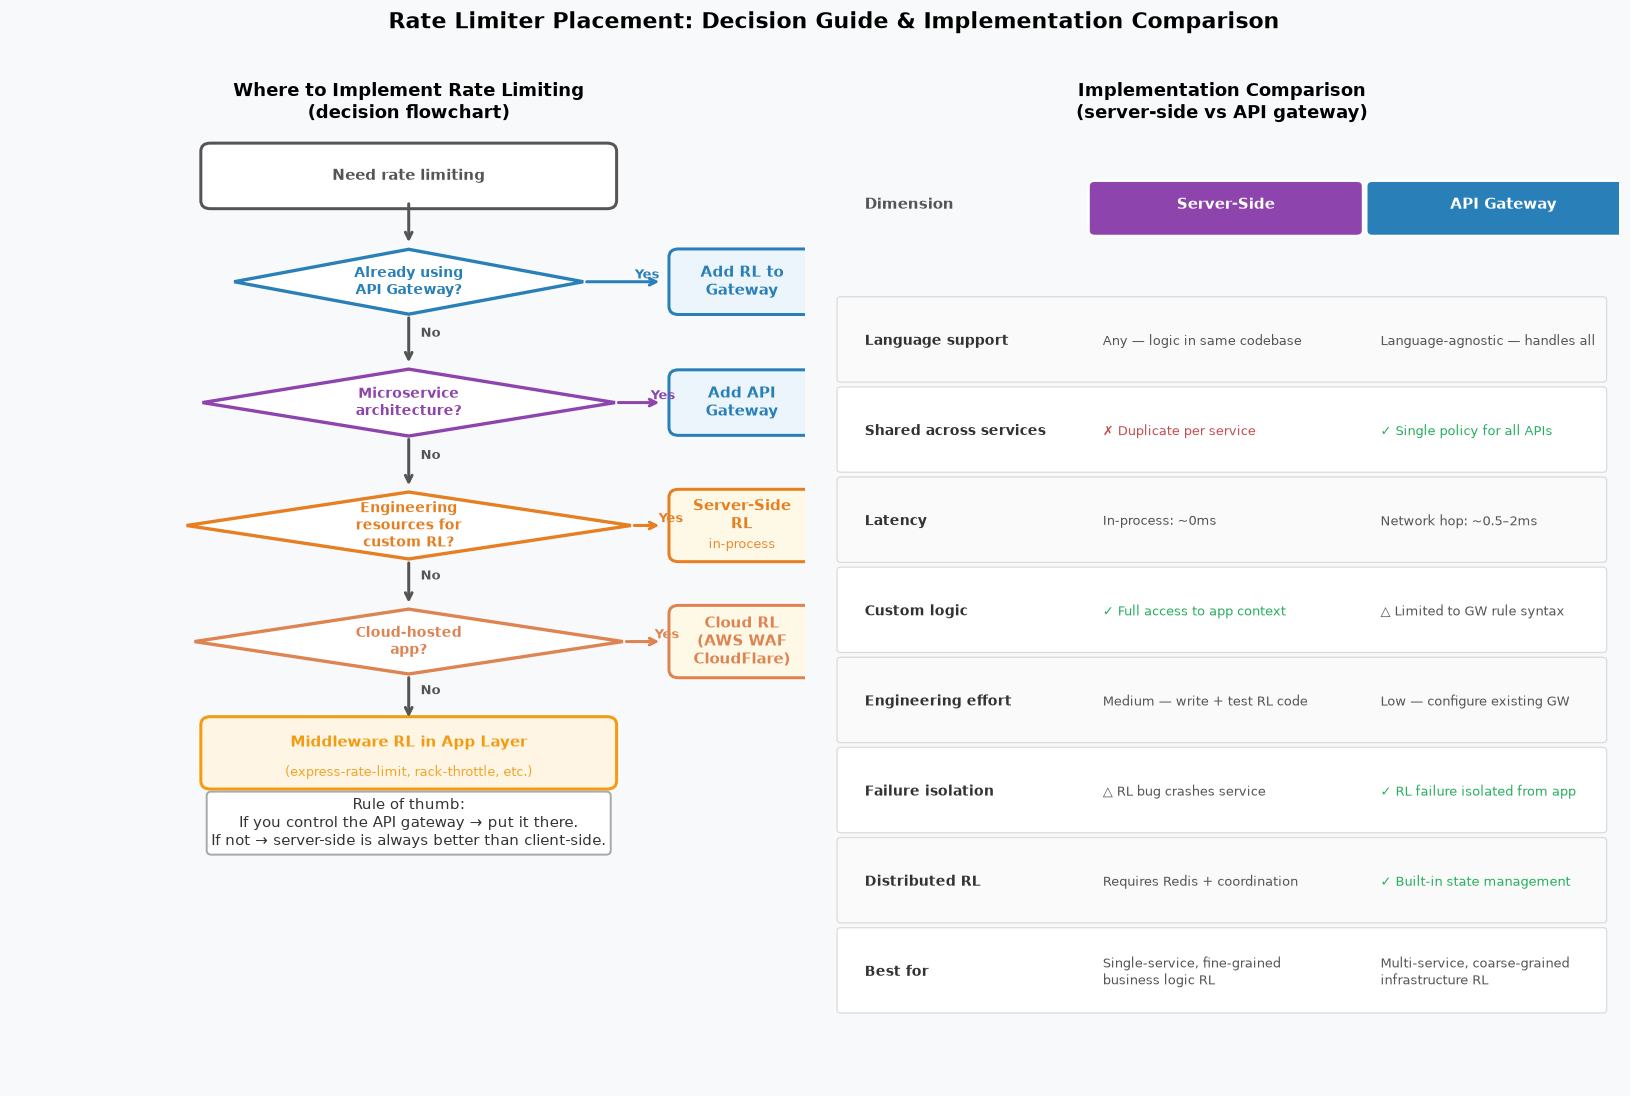

In [7]:
# Decision guide: when to use server-side RL vs API gateway

fig, axes = plt.subplots(1, 2, figsize=(14, 9))
fig.patch.set_facecolor(C_GRAY)

# ── Left: decision flowchart ───────────────────────────────────────────────────
ax = axes[0]
ax.set_xlim(0, 10); ax.set_ylim(0, 14)
ax.axis('off'); ax.set_facecolor(C_GRAY)
ax.set_title('Where to Implement Rate Limiting\n(decision flowchart)',
             fontsize=11, fontweight='bold')

def diamond(ax, x, y, w, h, label, color):
    cx, cy = x, y
    dx, dy = w/2, h/2
    pts = [(cx, cy+dy), (cx+dx, cy), (cx, cy-dy), (cx-dx, cy)]
    poly = plt.Polygon(pts, facecolor='white', edgecolor=color, lw=2.0)
    ax.add_patch(poly)
    ax.text(cx, cy, label, ha='center', va='center',
            fontsize=8.5, fontweight='bold', color=color,
            wrap=True)

def rect(ax, x, y, w, h, label, color, bg='white', sub=''):
    r = FancyBboxPatch((x - w/2, y - h/2), w, h,
                       boxstyle='round,pad=0.12',
                       facecolor=bg, edgecolor=color, lw=1.8)
    ax.add_patch(r)
    ax.text(x, y + (0.15 if sub else 0), label, ha='center', va='center',
            fontsize=9, fontweight='bold', color=color)
    if sub:
        ax.text(x, y - 0.28, sub, ha='center', va='center',
                fontsize=7.5, color=color, alpha=0.9)

def farr(ax, x1, y1, x2, y2, label='', color='#555'):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.8))
    if label:
        mx, my = (x1+x2)/2 + 0.15, (y1+y2)/2 + 0.1
        ax.text(mx, my, label, ha='left', va='center', fontsize=8,
                color=color, fontweight='bold')

rect(ax, 5.0, 13.3, 5.0, 0.72, 'Need rate limiting', '#555', bg='white')

farr(ax, 5.0, 12.94, 5.0, 12.28, '', '#555')
diamond(ax, 5.0, 11.75, 4.4, 0.95, 'Already using\nAPI Gateway?', C_GW)

# Yes → add to gateway
farr(ax, 7.2, 11.75, 8.2, 11.75, 'Yes', C_GW)
rect(ax, 9.2, 11.75, 1.6, 0.72, 'Add RL to\nGateway', C_GW, bg='#EBF5FB')

# No → next question
farr(ax, 5.0, 11.27, 5.0, 10.52, 'No', '#555')
diamond(ax, 5.0, 9.98, 5.2, 0.98, 'Microservice\narchitecture?', C_SERVER)

# Yes → build gateway + RL
farr(ax, 7.6, 9.98, 8.2, 9.98, 'Yes', C_SERVER)
rect(ax, 9.2, 9.98, 1.6, 0.72, 'Add API\nGateway', C_GW, bg='#EBF5FB')

# No → next
farr(ax, 5.0, 9.49, 5.0, 8.72, 'No', '#555')
diamond(ax, 5.0, 8.18, 5.6, 0.98, 'Engineering\nresources for\ncustom RL?', C_RL)

# Yes → server-side
farr(ax, 7.8, 8.18, 8.2, 8.18, 'Yes', C_RL)
rect(ax, 9.2, 8.18, 1.6, 0.82, 'Server-Side\nRL', C_RL, bg='#FEF9E7',
     sub='in-process')

# No → managed service
farr(ax, 5.0, 7.68, 5.0, 7.0, 'No', '#555')
diamond(ax, 5.0, 6.48, 5.4, 0.95, 'Cloud-hosted\napp?', C_ORANGE)

# Yes → cloud managed
farr(ax, 7.7, 6.48, 8.2, 6.48, 'Yes', C_ORANGE)
rect(ax, 9.2, 6.48, 1.6, 0.82, 'Cloud RL\n(AWS WAF\nCloudFlare)', C_ORANGE,
     bg='#FEF9E7')

# No → third-party library
farr(ax, 5.0, 6.0, 5.0, 5.32, 'No', '#555')
rect(ax, 5.0, 4.85, 5.0, 0.82, 'Middleware RL in App Layer', C_MIDDLE,
     bg='#FEF5E4', sub='(express-rate-limit, rack-throttle, etc.)')

ax.text(5.0, 3.5,
        'Rule of thumb:\nIf you control the API gateway → put it there.\n'
        'If not → server-side is always better than client-side.',
        ha='center', fontsize=9, color='#333',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                  edgecolor='#aaa', lw=1.2))

# ── Right: comparison table ────────────────────────────────────────────────────
ax = axes[1]
ax.set_xlim(0, 10); ax.set_ylim(0, 14)
ax.axis('off'); ax.set_facecolor(C_GRAY)
ax.set_title('Implementation Comparison\n(server-side vs API gateway)',
             fontsize=11, fontweight='bold')

headers = ['Dimension', 'Server-Side', 'API Gateway']
col_x2 = [0.5, 3.5, 7.0]
hdr_colors = ['#555', C_SERVER, C_GW]

# Header row
for cx, hdr, hcol in zip(col_x2, headers, hdr_colors):
    if cx != col_x2[0]:
        r = FancyBboxPatch((cx - 0.1, 12.5), 3.3, 0.65,
                           boxstyle='round,pad=0.08',
                           facecolor=hcol, edgecolor='white', lw=1.5)
        ax.add_patch(r)
        ax.text(cx + 1.55, 12.82, hdr, ha='center', fontsize=9,
                fontweight='bold', color='white')
    else:
        ax.text(cx, 12.82, hdr, ha='left', fontsize=9,
                fontweight='bold', color=hcol)

rows = [
    ('Language support',
     'Any — logic in same codebase',
     'Language-agnostic — handles all'),
    ('Shared across services',
     '✗ Duplicate per service',
     '✓ Single policy for all APIs'),
    ('Latency',
     'In-process: ~0ms',
     'Network hop: ~0.5–2ms'),
    ('Custom logic',
     '✓ Full access to app context',
     '△ Limited to GW rule syntax'),
    ('Engineering effort',
     'Medium — write + test RL code',
     'Low — configure existing GW'),
    ('Failure isolation',
     '△ RL bug crashes service',
     '✓ RL failure isolated from app'),
    ('Distributed RL',
     'Requires Redis + coordination',
     '✓ Built-in state management'),
    ('Best for',
     'Single-service, fine-grained\nbusiness logic RL',
     'Multi-service, coarse-grained\ninfrastructure RL'),
]

y0 = 12.2
for dim, sv, gw in rows:
    y0 -= 1.32
    bg = '#FAFAFA' if rows.index((dim, sv, gw)) % 2 == 0 else 'white'
    r = FancyBboxPatch((0.2, y0 - 0.55), 9.6, 1.15,
                       boxstyle='round,pad=0.05',
                       facecolor=bg, edgecolor='#ddd', lw=0.8)
    ax.add_patch(r)
    ax.text(col_x2[0], y0, dim, ha='left', va='center',
            fontsize=8.5, fontweight='bold', color='#333')
    sv_c = C_ALLOW if sv.startswith('✓') else (C_BLOCK if sv.startswith('✗') else '#555')
    gw_c = C_ALLOW if gw.startswith('✓') else (C_BLOCK if gw.startswith('✗') else '#555')
    ax.text(col_x2[1], y0, sv, ha='left', va='center', fontsize=8, color=sv_c)
    ax.text(col_x2[2], y0, gw, ha='left', va='center', fontsize=8, color=gw_c)

plt.suptitle('Rate Limiter Placement: Decision Guide & Implementation Comparison',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/tmp/sd_day11_decision.png', dpi=130, bbox_inches='tight')
plt.show()


### What these diagrams show

**Left — Decision flowchart:**  
A series of diamond decision nodes walks through the four questions from the post: do you have an API gateway? Is this a microservice architecture? Do you have engineering resources for a custom RL? Is it cloud-hosted? Each 'Yes' branch terminates at the recommended implementation. The rule-of-thumb box at the bottom summarises the heuristic.

**Right — Comparison table:**  
Eight dimensions compared between server-side and API gateway implementations. Green ✓ marks clear advantages; red ✗ marks limitations. Language support, shared policy, latency, custom logic, engineering effort, failure isolation, distributed consistency, and best-for scenario are all covered.

## 8. Architecture Evolution & Scorecard

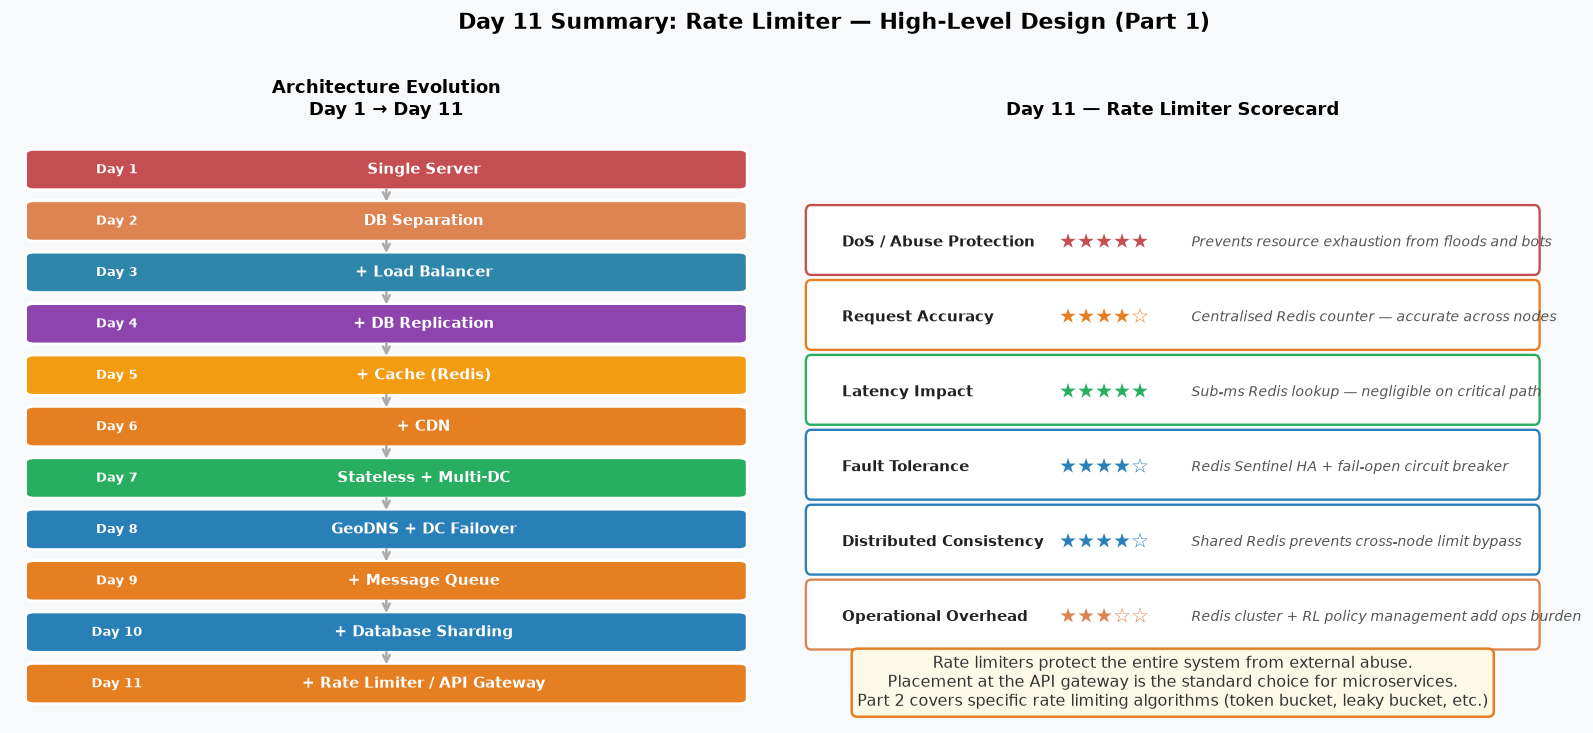

Day 11 complete.


In [8]:
# Day 11 scorecard + evolution Day 1 → 11

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor(C_GRAY)

# ── Left: evolution ────────────────────────────────────────────────────────────
ax = axes[0]
ax.set_xlim(0, 10); ax.set_ylim(0, 16)
ax.axis('off'); ax.set_facecolor(C_GRAY)
ax.set_title('Architecture Evolution\nDay 1 → Day 11', fontsize=11, fontweight='bold')

days = [
    ('Day 1',  'Single Server',                '#C44E52'),
    ('Day 2',  'DB Separation',                '#DD8452'),
    ('Day 3',  '+ Load Balancer',              '#2E86AB'),
    ('Day 4',  '+ DB Replication',             '#8E44AD'),
    ('Day 5',  '+ Cache (Redis)',              '#F39C12'),
    ('Day 6',  '+ CDN',                        '#E67E22'),
    ('Day 7',  'Stateless + Multi-DC',         '#27AE60'),
    ('Day 8',  'GeoDNS + DC Failover',         '#2980B9'),
    ('Day 9',  '+ Message Queue',              '#E67E22'),
    ('Day 10', '+ Database Sharding',          '#2980B9'),
    ('Day 11', '+ Rate Limiter / API Gateway', C_RL),
]
ys = np.linspace(14.8, 1.0, len(days))
for i, ((day, label, color), y) in enumerate(zip(days, ys)):
    r = FancyBboxPatch((0.3, y - 0.42), 9.4, 0.85,
                       boxstyle='round,pad=0.12',
                       facecolor=color, edgecolor='white', lw=1.8)
    ax.add_patch(r)
    ax.text(1.4, y, day, ha='center', va='center',
            fontsize=8, fontweight='bold', color='white')
    ax.text(5.5, y, label, ha='center', va='center',
            fontsize=9, fontweight='bold', color='white')
    if i < len(days) - 1:
        ax.annotate('', xy=(5, ys[i+1] + 0.43), xytext=(5, y - 0.43),
                    arrowprops=dict(arrowstyle='->', color='#aaa', lw=1.5))

# ── Right: scorecard ──────────────────────────────────────────────────────────
ax = axes[1]
ax.set_xlim(0, 12); ax.set_ylim(0, 7)
ax.axis('off'); ax.set_facecolor(C_GRAY)
ax.set_title('Day 11 — Rate Limiter Scorecard', fontsize=11, fontweight='bold')

metrics = [
    ('DoS / Abuse Protection',  '★★★★★', C_BLOCK,
     'Prevents resource exhaustion from floods and bots'),
    ('Request Accuracy',        '★★★★☆', C_RL,
     'Centralised Redis counter — accurate across nodes'),
    ('Latency Impact',          '★★★★★', C_ALLOW,
     'Sub-ms Redis lookup — negligible on critical path'),
    ('Fault Tolerance',         '★★★★☆', C_GW,
     'Redis Sentinel HA + fail-open circuit breaker'),
    ('Distributed Consistency', '★★★★☆', C_GW,
     'Shared Redis prevents cross-node limit bypass'),
    ('Operational Overhead',    '★★★☆☆', C_ORANGE,
     'Redis cluster + RL policy management add ops burden'),
]

y0 = 6.5
for (metric, stars, color, detail) in metrics:
    y0 -= 0.88
    r = FancyBboxPatch((0.2, y0 - 0.3), 11.6, 0.66,
                       boxstyle='round,pad=0.08',
                       facecolor='white', edgecolor=color, lw=1.4)
    ax.add_patch(r)
    ax.text(0.7,  y0, metric, ha='left',   va='center',
            fontsize=9,  fontweight='bold', color='#222')
    ax.text(4.9,  y0, stars,  ha='center', va='center',
            fontsize=12, color=color)
    ax.text(6.3,  y0, detail, ha='left',   va='center',
            fontsize=8.5, color='#555', fontstyle='italic')

ax.text(6, 0.45,
        'Rate limiters protect the entire system from external abuse.\n'
        'Placement at the API gateway is the standard choice for microservices.\n'
        'Part 2 covers specific rate limiting algorithms (token bucket, leaky bucket, etc.)',
        ha='center', va='center', fontsize=9.5, color='#333',
        bbox=dict(boxstyle='round,pad=0.35', facecolor='#FEF9E7',
                  edgecolor=C_RL, lw=1.5))

plt.suptitle('Day 11 Summary: Rate Limiter — High-Level Design (Part 1)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/tmp/sd_day11_scorecard.png', dpi=130, bbox_inches='tight')
plt.show()
print("Day 11 complete.")


### What this shows

**Left — Evolution Day 1 → Day 11:**  
Day 11 adds the rate limiter and API gateway as the traffic control layer, sitting in front of all the services built in Days 3–10. The amber Day 11 bar visually matches the amber `C_RL` colour used throughout the day.

**Right — Day 11 Scorecard:**
- **DoS / Abuse Protection (5/5):** Prevents resource exhaustion from floods and bots.
- **Request Accuracy (4/5):** Centralised Redis counter is accurate across nodes; slight race window in high-contention scenarios.
- **Latency Impact (5/5):** Sub-millisecond Redis lookup — negligible on the critical path.
- **Fault Tolerance (4/5):** Redis Sentinel HA + fail-open circuit breaker handles Redis outages.
- **Distributed Consistency (4/5):** Shared Redis prevents cross-node bypass; Redis cluster partitioning can introduce split-brain edge cases.
- **Operational Overhead (3/5):** Redis cluster + rate limit policy management + DDoS response playbooks add ops burden.

**What's next:** Part 2 (Day 12) covers the specific rate limiting algorithms — token bucket, leaky bucket, fixed window counter, sliding window log, and sliding window counter — with visualisations of how each handles burst traffic.